In [1]:
!git clone https://github.com/ajurcik/MLPrague-2026-test.git
!pip install ./MLPrague-2026-test

!pip install -r MLPrague-2026-test/requirements.txt

fatal: destination path 'MLPrague-2026-test' already exists and is not an empty directory.
Processing ./MLPrague-2026-test
  Preparing metadata (setup.py) ... done
  Created wheel for szn-advertising-research-ml-prague-2026: filename=szn_advertising_research_ml_prague_2026-0.0.1-py3-none-any.whl size=9111 sha256=041c97563a875e72e647e446e22c84abeb89b1d1fa50dfd39d70120c3521c0ca
  Stored in directory: /root/.cache/pip/wheels/d8/cb/42/cd041f010ad9bbdf861958c75fcaf86ce5f7d307ccef42e0f8
Successfully built szn-advertising-research-ml-prague-2026
  Attempting uninstall: szn-advertising-research-ml-prague-2026
    Found existing installation: szn-advertising-research-ml-prague-2026 0.0.1
    Uninstalling szn-advertising-research-ml-prague-2026-0.0.1:
      Successfully uninstalled szn-advertising-research-ml-prague-2026-0.0.1
Looking in links: https://data.pyg.org/whl/torch-2.8.0+cu128.html


# Anomaly Detection on Graphs — Hands-on Workshop

In this notebook you will apply several anomaly detection methods to the **YelpChi** fraud-review dataset.  
The dataset contains Yelp reviews with hand-crafted features and a binary `spam` label. Reviews are connected through edges, forming a graph.

**Models we will train & compare:**
1. **Isolation Forest** — a classical tree-based anomaly detector
2. **Autoencoder** — Leveraging autoencoder architecture for anomaly detection
3. **GAE** — Graph Auto Encoder (PyGOD)
4. **CoLA** — Anomaly Detection on Attributed Networks via Contrastive Self-Supervised Learning​ (PyGOD)

In [17]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from torch_geometric.transforms import RandomLinkSplit
from sklearn.metrics import classification_report
from sklearn.preprocessing import minmax_scale

from ml_prague_2026.evaluation import compare_models, evaluate_model

from pygod.detector import DOMINANT, GADNR

import torch
import torch.nn as tnn
import torch_geometric.nn as nn
import torch_geometric.utils as utils
import torch.nn.functional as F
from torch_geometric.utils import add_self_loops
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
from torch_geometric.seed import seed_everything
from torch_geometric.utils import degree as pyg_degree
from sklearn.preprocessing import StandardScaler


seed_everything(23)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [3]:
YELP_CHI_PATH = 'MLPrague-2026-test/data/yelpchi.parquet'

YELP_CHI_EDGE_RSR_PATH = 'MLPrague-2026-test/data/yelpchi_rsr.npy'
YELP_CHI_EDGE_RTR_PATH = 'MLPrague-2026-test/data/yelpchi_rtr.npy'
YELP_CHI_EDGE_RUR_PATH = 'MLPrague-2026-test/data/yelpchi_rur.npy'

## 1. Data Loading

We start by loading the preprocessed YelpChi dataset (reviews with features) and the three edge lists that connect reviews sharing the same restaurant, timestamp, or user.

In [4]:
yelp_chi = pd.read_parquet(YELP_CHI_PATH)
yelp_chi.head(2)

,date,review_id,user_id,product_id,spam,useful,funny,cool,stars,review,...,f_23,f_24,f_25,f_26,f_27,f_28,f_29,f_30,f_31,review_idx
0,2011-06-08,MyNjnxzZVTPq,IFTr6_6NI4CgCVavIL9k5g,tQfLGoolUMu2J0igcWcoZg,0,28,11,18,5,Let me begin by saying that there are two kind...,...,0.867772,0.995025,0.910448,0.079602,0.00995,0.014925,0.59204,0.139303,0.497512,0
1,2011-08-30,BdD7fsPqHQL73hwENEDT-Q,c_-hF15XgNhlyy_TqzmdaA,tQfLGoolUMu2J0igcWcoZg,0,4,3,0,3,The only place inside the Loop that you can st...,...,0.826367,0.995025,0.910448,0.079602,0.00995,0.014925,0.59204,0.139303,0.497512,1


In [5]:
edges = np.concatenate((
    np.load(YELP_CHI_EDGE_RSR_PATH, allow_pickle=True),
    np.load(YELP_CHI_EDGE_RTR_PATH, allow_pickle=True),
    np.load(YELP_CHI_EDGE_RUR_PATH, allow_pickle=True)
), axis=0)

## 2. Isolation Forest

[Isolation Forest](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.IsolationForest.html) is a tree-based anomaly detector that works on tabular features **without** graph structure.  
It isolates anomalies by randomly partitioning features — anomalies require fewer splits, resulting in shorter average path lengths.

In [6]:
# Prepare features and labels
feature_cols = [c for c in yelp_chi.columns if c.startswith('f_')]
X = yelp_chi[feature_cols].values
y_true = yelp_chi['spam'].values


# Graph-augmented features
def undirected_degree(edge_index: torch.Tensor, num_nodes: int) -> np.ndarray:
    """Sum degrees from both directions to handle undirected edges."""
    return (
        pyg_degree(edge_index[0], num_nodes=num_nodes)
        + pyg_degree(edge_index[1], num_nodes=num_nodes)
    ).numpy()

n_nodes = len(yelp_chi)
edge_paths = {
    "rur": YELP_CHI_EDGE_RUR_PATH,
    "rsr": YELP_CHI_EDGE_RSR_PATH,
    "rtr": YELP_CHI_EDGE_RTR_PATH,
}

degree_features = []
for path in edge_paths.values():
    edges = torch.tensor(np.load(path, allow_pickle=True).T, dtype=torch.long)
    degree_features.append(undirected_degree(edges, n_nodes)[:, None])

X_aug = np.concatenate([X, *degree_features], axis=1)

# Load train/test split from file (to ensure consistency with supervised notebook)
data_split = np.load('MLPrague-2026-test/data/yelpchi_split.npz')
train_idx = np.concatenate([data_split['train'], data_split['val']])
test_idx = data_split['test']

X_train, X_test = X_aug[train_idx], X_aug[test_idx]
y_train, y_test = y_true[train_idx], y_true[test_idx]

We use the known **contamination rate** (fraction of spam) so the model threshold matches the true anomaly ratio.

In [7]:
# Contamination approximates the fraction of anomalies (spam) in the dataset
contamination = y_train.mean()
print(f'Contamination (proportion of anomalies): {contamination:.4f}')

Contamination (proportion of anomalies): 0.1453


### TASK 1.A: Experiment with contamination

In [82]:
# TASK 1.A: experiment with the contamination parameter
# - Try different values for contamination (e.g., 0.1, 0.2...)
# - Observe how it affects the recall and precision of the model on anomaly class

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=contamination,
    random_state=42,
    n_jobs=-1,
)

iso_forest.fit(X_train)

IsolationForest(contamination=np.float64(0.14531309504379522), n_estimators=200,
                n_jobs=-1, random_state=42)

In [83]:
# IsolationForest returns -1 for anomalies, 1 for normal
y_pred_test = (iso_forest.predict(X_test) == -1).astype(int)

# Compute anomaly scores — negate score_samples so that higher = more anomalous
y_scores_test = -iso_forest.score_samples(X_test)
y_scores_test

array([0.55669488, 0.49751465, 0.50879919, ..., 0.46719504, 0.49229824,
       0.5341797 ])

In [87]:
# Sklearn classification report
print(classification_report(y_test, y_pred_test))

# Evaluate
isolation_forest_results = evaluate_model('isolation_forest', y_test, y_pred_test, y_scores_test)

              precision    recall  f1-score   support

           0       0.88      0.87      0.87      7857
           1       0.26      0.28      0.27      1335

    accuracy                           0.78      9192
   macro avg       0.57      0.57      0.57      9192
weighted avg       0.79      0.78      0.78      9192



,Precision,Recall,AUPRC,Rec@K
0,0.569,0.572,0.233,0.27


## 3. Autoencoder

An **Autoencoder** is a neural network trained to compress input data into a compact latent representation and then reconstruct it.
It consists of an **encoder** (input → latent space) and a **decoder** (latent space → reconstruction).
Model learns well majority class (normal class) and anomalies produce higher reconstruction error because they fall outside the distribution the model learned.

Here we use a **Masking Autoencoder** variant: during training, a random fraction of input features is zeroed out,
forcing the model to reconstruct missing values and learn more robust representations.

For anomaly scoring we are using combination of reconstruction score and anomaly score from Isolation forest trained on latent space.

<img src="https://raw.githubusercontent.com/ajurcik/MLPrague-2026-test/refs/heads/master/presentation/images/ae.png" width="600">

In [111]:
# Scale feature vector
scaler = StandardScaler()
X_aug_train = scaler.fit_transform(X_aug[train_idx].astype(np.float32))
X_aug_test = scaler.transform(X_aug[test_idx].astype(np.float32))

X_train_t = torch.tensor(X_aug_train, dtype=torch.float32, device=device)
X_test_t = torch.tensor(X_aug_test,  dtype=torch.float32, device=device)

##### Model

In [112]:
class MaskingAutoencoder(tnn.Module):
    def __init__(self, input_dim: int, hidden_dim: int = 128, latent_dim: int = 16, dropout: float = 0.2):
        super().__init__()
        # The encoder compresses the input into a lower-dimensional latent representation.
        self.encoder = tnn.Sequential(
            tnn.Linear(input_dim, hidden_dim), tnn.Mish(), tnn.Dropout(dropout),
            tnn.Linear(hidden_dim, hidden_dim // 2), tnn.Mish(), tnn.Dropout(dropout),
            tnn.Linear(hidden_dim // 2, hidden_dim // 4), tnn.Mish(),
            tnn.Linear(hidden_dim // 4, latent_dim),
        )
        # The decoder attempts to reconstruct the original input from the latent representation.
        self.decoder = tnn.Sequential(
            tnn.Linear(latent_dim, hidden_dim // 4), tnn.Mish(), tnn.Dropout(dropout),
            tnn.Linear(hidden_dim // 4, hidden_dim // 2), tnn.Mish(), tnn.Dropout(dropout),
            tnn.Linear(hidden_dim // 2, hidden_dim), tnn.Mish(),
            tnn.Linear(hidden_dim, input_dim),
        )

    def forward(self, x, mask_ratio=0):
        # During training, randomly mask out a portion of the input features
        # This forces the model to learn robust representations by reconstructing missing parts.
        if mask_ratio > 0 and self.training:
            mask = (torch.rand_like(x) > mask_ratio).float()
            x_masked = x * mask
        else:
            x_masked = x
        # Pass the input through the encoder
        z = self.encoder(x_masked)
        # Reconstruct the output using the decoder
        return self.decoder(z), z

##### Train and eval functions

In [113]:
def combined_loss(recon, target, alpha=0.7):
    ### Combine MSE and cosine similarity
    mse = tnn.functional.mse_loss(recon, target)
    cos = 1 - tnn.functional.cosine_similarity(recon, target, dim=1).mean()
    return alpha * mse + (1 - alpha) * cos


def train_autoencoder(model, X_train_t, epochs=500, lr=1e-3, weight_decay=1e-4,
                      mask_ratio=0.25, loss_alpha=0.7, print_every=100):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)

    model.train()
    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()

        # Forward pass: get reconstructions from the model, applying masking
        recon, _ = model(X_train_t, mask_ratio=mask_ratio)

        # Compute the loss between reconstructions and original inputs
        loss = combined_loss(recon, X_train_t, alpha=loss_alpha)

        loss.backward()
        optimizer.step()
        scheduler.step()

        if print_every and epoch % print_every == 0:
            print(f"Epoch {epoch:03d} | Loss: {loss.item():.5f}")

    return model


def evaluate_autoencoder(model, X_train_t, X_test_t, y_test, contamination=0.05,
                         rec_weight=0.3, iso_weight=0.7, loss_alpha=0.7,
                         iso_kwargs=None):
    model.eval()
    with torch.no_grad(): # Disable gradient calculation for inference
        # Get reconstructions and latent embeddings for test data
        recon_test, z_test = model(X_test_t)
        # Get latent embeddings for train data to fit the Isolation Forest
        _, z_train = model(X_train_t)

    # 1. Compute Reconstruction-based anomaly scores
    rec_mse = ((recon_test - X_test_t) ** 2).mean(dim=1).cpu().numpy()
    rec_cos = (1 - tnn.functional.cosine_similarity(recon_test, X_test_t, dim=1)).cpu().numpy()
    rec_combined = loss_alpha * minmax_scale(rec_mse) + (1 - loss_alpha) * minmax_scale(rec_cos)

    z_train_np = z_train.cpu().numpy()
    z_test_np = z_test.cpu().numpy()

    # 2. Compute Latent space anomaly scores using Isolation Forest
    iso_params = dict(contamination=contamination, random_state=42, n_estimators=300)
    if iso_kwargs:
        iso_params.update(iso_kwargs)
    iso = IsolationForest(**iso_params)
    iso.fit(z_train_np)
    iso_scores = -iso.score_samples(z_test_np)

    # 3. Ensemble both scores
    ensemble_scores = rec_weight * minmax_scale(rec_combined) + iso_weight * minmax_scale(iso_scores)

    # Threshold the ensemble scores based on the expected contamination rate
    threshold = np.percentile(ensemble_scores, 100 * (1 - contamination))
    ensemble_preds = (ensemble_scores >= threshold).astype(int)

    return evaluate_model("autoencoder", y_test, ensemble_preds, ensemble_scores)

In [116]:
# Define and train model
model = MaskingAutoencoder(X_aug.shape[1]).to(device)
model = train_autoencoder(model, X_train_t)

Epoch 100 | Loss: 0.66605
Epoch 200 | Loss: 0.56239
Epoch 300 | Loss: 0.53258
Epoch 400 | Loss: 0.52315
Epoch 500 | Loss: 0.52205


In [117]:
autoencoder_results = evaluate_autoencoder(model, X_train_t, X_test_t, y_test, contamination=contamination)

,Precision,Recall,AUPRC,Rec@K
0,0.584,0.585,0.252,0.29


## 4. GAE

GAE uses a graph neural network to directly learn node representations that reconstruct the original node features. Nodes with high reconstruction error (i.e., those the model fails to reconstruct well) are flagged as anomalies.

<img src="https://raw.githubusercontent.com/ajurcik/MLPrague-2026-test/refs/heads/master/presentation/images/gae.png" width="600">

We use the [PyGOD](https://docs.pygod.org/) implementation which handles training.

#### Building the PyTorch Geometric Graph

To use GNN-based detectors we need a `torch_geometric.Data` object that bundles:
- **`x`** — node feature matrix of shape `(num_nodes, num_features)`
- **`edge_index`** — edge list as a `(2, num_edges)` tensor with contiguous node indices
- **`y`** — ground-truth labels (used only for evaluation, not for training)

In [12]:
# Create edge index tensor
edge_index = torch.tensor(edges, dtype=torch.long)
if edge_index.shape[0] != 2:
    edge_index = edge_index.t()
edge_index = edge_index.contiguous()

# Add undirected edges (since the graph is undirected)
edge_index = utils.to_undirected(edge_index)

# Extract node features — select all columns that start with 'f_'
feature_cols = [c for c in yelp_chi.columns if c.startswith('f_')]
x = torch.tensor(yelp_chi[feature_cols].values, dtype=torch.float)

# Extract labels from the 'spam' column
y = torch.tensor(yelp_chi['spam'].values, dtype=torch.long)

# Create the PyTorch Geometric Data object with x, edge_index, and y
pytorch_data = Data(x=x, edge_index=edge_index, y=y)
pytorch_data.to(device)

pytorch_data

Data(x=[45954, 30], edge_index=[2, 1147232], y=[45954])

In [13]:
# Apply train/test split to the PyG data object via masks
pytorch_data.train_mask = torch.zeros(pytorch_data.num_nodes, dtype=torch.bool)
pytorch_data.test_mask = torch.zeros(pytorch_data.num_nodes, dtype=torch.bool)
pytorch_data.train_mask[train_idx] = True
pytorch_data.test_mask[test_idx] = True
pytorch_data

Data(x=[45954, 30], edge_index=[2, 1147232], y=[45954], train_mask=[45954], test_mask=[45954])

### TASK 4.A - Define GAE model

In [65]:
# TASK 4.A: defining and fitting GAE model
# - Start by opening https://docs.pygod.org/ and search for GAE model
# - Define GAE model with main parameters (e.g., hidden dimension, number of layers, epochs, etc.)
# - Do not forget assigning contamination parameter, gpu=0 and verbose=3 level to the model
# - Fit the model on the PyTorch Geometric data object (pytorch_data)

from pygod.detector import GAE

model_unsupervised_gae = ### YOUR CODE HERE ###

<details>
<summary><b>Task 3 — Solution example</b></summary>

```python
model_unsupervised_gae = GAE(
    hid_dim=32,
    num_layers=2,
    epoch=50,
    verbose=3,
    contamination=contamination,
    dropout=0.3,
    gpu=0
)
model_unsupervised_gae.fit(pytorch_data)
```

</details>

In [42]:
gae_preds, gae_preds_proba = model_unsupervised_gae.predict(pytorch_data, return_prob=True)

Test: Loss 0.0816 |  | Time 0.06


In [43]:
gae_results = evaluate_model(
    'gae',
    pytorch_data.y[pytorch_data.test_mask].cpu().numpy(),
    gae_preds[pytorch_data.test_mask],
    gae_preds_proba[pytorch_data.test_mask],
)

,Precision,Recall,AUPRC,Rec@K
0,0.551,0.552,0.206,0.233


## 5. CoLA

CoLA learns to detect anomalies by using contrastive learning, where it compares a node with its real local neighborhood (positive pair) and with random neighborhoods (negative pairs) to learn what “normal” consistency looks like. Nodes that consistently don’t match their surrounding subgraph (i.e., low positive similarity and high negative similarity) are assigned higher anomaly scores.

<img src="https://raw.githubusercontent.com/ajurcik/MLPrague-2026-test/refs/heads/master/presentation/images/cola.png" width="600">

We use the [PyGOD](https://docs.pygod.org/) implementation which handles training.

In [75]:
from pygod.detector import CoLA

model_unsupervised_cola = CoLA(
    hid_dim=64,
    num_layers=2,
    epoch=50,
    verbose=3,
    contamination=contamination,
    dropout=0.2,
    gpu=0
)
model_unsupervised_cola = model_unsupervised_cola.fit(pytorch_data)

Epoch 0000: Loss 0.8943 |  | Time 0.07
Epoch 0001: Loss 1.2316 |  | Time 0.07
Epoch 0002: Loss 0.8751 |  | Time 0.07
Epoch 0003: Loss 0.7265 |  | Time 0.07
Epoch 0004: Loss 0.8202 |  | Time 0.07
Epoch 0005: Loss 0.8247 |  | Time 0.07
Epoch 0006: Loss 0.7547 |  | Time 0.07
Epoch 0007: Loss 0.7029 |  | Time 0.07
Epoch 0008: Loss 0.7024 |  | Time 0.07
Epoch 0009: Loss 0.7277 |  | Time 0.07
Epoch 0010: Loss 0.7423 |  | Time 0.07
Epoch 0011: Loss 0.7345 |  | Time 0.07
Epoch 0012: Loss 0.7154 |  | Time 0.07
Epoch 0013: Loss 0.6985 |  | Time 0.07
Epoch 0014: Loss 0.6908 |  | Time 0.07
Epoch 0015: Loss 0.6928 |  | Time 0.07
Epoch 0016: Loss 0.6993 |  | Time 0.07
Epoch 0017: Loss 0.7025 |  | Time 0.07
Epoch 0018: Loss 0.7005 |  | Time 0.07
Epoch 0019: Loss 0.6958 |  | Time 0.07
Epoch 0020: Loss 0.6910 |  | Time 0.07
Epoch 0021: Loss 0.6878 |  | Time 0.07
Epoch 0022: Loss 0.6873 |  | Time 0.07
Epoch 0023: Loss 0.6883 |  | Time 0.07
Epoch 0024: Loss 0.6887 |  | Time 0.09
Epoch 0025: Loss 0.6879 |

In [76]:
cola_preds, cola_preds_proba = model_unsupervised_cola.predict(pytorch_data, return_prob=True)

Test: Loss 0.6668 |  | Time 0.06


In [77]:
cola_results = evaluate_model(
    'CoLA',
    pytorch_data.y[pytorch_data.test_mask].cpu().numpy(),
    cola_preds[pytorch_data.test_mask],
    cola_preds_proba[pytorch_data.test_mask],
)

,Precision,Recall,AUPRC,Rec@K
0,0.49,0.49,0.141,0.131


## 6. Final comparison

Let's compare all models side-by-side.

,Precision,Recall,AUPRC,Rec@K
Model,,,,
isolation_forest,0.569,0.572,0.233,0.270
graph_aug_autoencoder_v2,0.557,0.557,0.200,0.243
deep_mae_combined_loss,0.588,0.588,0.258,0.295
gae,0.551,0.552,0.206,0.233
cola,0.489,0.489,0.135,0.126


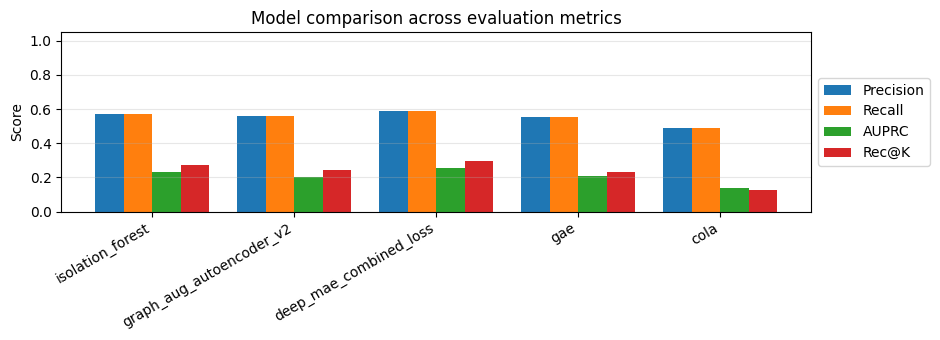

In [62]:
models_results = compare_models([
    isolation_forest_results,
    autoencoder_results,
    gae_results,
    cola_results,
])